In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import keras as ks

df = pd.read_csv("/content/data.csv")

In [ ]:
from sklearn.preprocessing import StandardScaler

target_col = "Restormel 10SRE01"
time_features = ["hour", "day_of_week", "month", "day", "is_weekend"]
all_features = [target_col] + time_features

df = df[all_features]
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.values)
data = pd.DataFrame(df_scaled, columns=df.columns, index=df.index)

df.index = pd.date_range("2024-01-01", periods=len(data), freq="h")
df.index.name = "datetime"

target_col = 'Restormel 10SRE01'
feature_cols = df.columns.tolist()
feature_cols.remove(target_col)

In [ ]:
# Forecast horizon
pred_len = 672

# Decoder context
label_len = 504

# Encoder input length
seq_len = 336

# Stride for sliding window (e.g. every 24 hours)
stride = 6

# Target column
target_col = 'Restormel 10SRE01'


split_index = int(len(data) * 0.8)

buffer = seq_len + label_len + pred_len

train_data = data.iloc[:split_index]
test_data = data.iloc[split_index - buffer:]  # include buffer to build valid windows

In [ ]:
#Window function for Informer

def sliding_window_generator(data, seq_len = seq_len, label_len = label_len, pred_len=pred_len, stride = 6, target_col='Restormel 10SRE01'):
    X_enc, X_dec, Y = [], [], []
    max_len = seq_len + label_len + pred_len

    for start in range(0, len(data) - max_len, stride):
        enc_input = data.iloc[start:start + seq_len].values
        dec_input = data.iloc[start + seq_len - label_len : start + seq_len + pred_len].values
        label = data.iloc[start + seq_len : start + seq_len + pred_len][target_col].values

        X_enc.append(enc_input)
        X_dec.append(dec_input)
        Y.append(label[:, None])

    return (
        np.array(X_enc, dtype=np.float32),
        np.array(X_dec, dtype=np.float32),
        np.array(Y, dtype=np.float32)
    )

X_train_enc, X_train_dec, Y_train = sliding_window_generator(
    train_data, seq_len, label_len, pred_len, stride=stride, target_col=target_col
)

X_test_enc, X_test_dec, Y_test = sliding_window_generator(
    test_data, seq_len, label_len, pred_len, stride=stride, target_col=target_col
)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, regularizers
import numpy as np


class SinusoidalEncoding(layers.Layer):
    def __init__(self, d_model, max_len=2048):
        super().__init__()
        position = np.arange(max_len)[:, np.newaxis]
        div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(position * div_term)
        pe[:, 1::2] = np.cos(position * div_term)
        self.pos_encoding = tf.constant(pe[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pos_encoding[:, :seq_len, :]

class TransformerEncoderBlock(layers.Layer):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.2):
        super().__init__()
        self.attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            layers.Dense(d_ff, activation='relu'),
            layers.Dense(d_model)
        ])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()
        self.dropout = layers.Dropout(dropout)

    def call(self, x, training=True):
        x = self.norm1(x + self.dropout(self.attn(x, x), training=training))
        return self.norm2(x + self.dropout(self.ffn(x), training=training))

class TransformerDecoderBlock(layers.Layer):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model)
        self.cross_attn = layers.MultiHeadAttention(num_heads=n_heads, key_dim=d_model)
        self.ffn = tf.keras.Sequential([
            layers.Dense(d_ff, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
            layers.Dense(d_model, kernel_regularizer=regularizers.l2(1e-4))
        ])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()
        self.norm3 = layers.LayerNormalization()
        self.dropout = layers.Dropout(dropout)

    def call(self, x, enc_output, training=True):
        x = self.norm1(x + self.dropout(self.self_attn(x, x), training=training))
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_output), training=training))
        return self.norm3(x + self.dropout(self.ffn(x), training=training))

class SimpleInformer(tf.keras.Model):
    def __init__(self, input_dim, d_model=256, n_heads=8, d_ff=1024, dropout=0.1,
                 seq_len=168, label_len=72, pred_len=672):
        super().__init__()
        self.pred_len = pred_len
        self.label_len = label_len
        self.seq_len = seq_len

        self.input_proj = layers.Dense(d_model)
        self.pos_enc = SinusoidalEncoding(d_model)

        self.encoder_blocks = [TransformerEncoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(2)]
        self.decoder_blocks = [TransformerDecoderBlock(d_model, n_heads, d_ff, dropout)]

        self.output_proj = layers.Dense(1)

    def call(self, inputs, training=True):
        enc_input, dec_input = inputs

        enc = self.pos_enc(self.input_proj(enc_input))
        for block in self.encoder_blocks:
            enc = block(enc, training=training)

        dec = self.pos_enc(self.input_proj(dec_input))
        for block in self.decoder_blocks:
            dec = block(dec, enc, training=training)

        return self.output_proj(dec[:, -self.pred_len:, :])  # output last `pred_len` steps


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Instantiate model
model = SimpleInformer(
    input_dim=data.shape[1],
    seq_len=504,
    label_len=336,
    pred_len=672
)

# Compile
model.compile(optimizer='adam', loss='mse')

# Fit
model.fit(
    (X_train_enc, X_train_dec), Y_train,
    validation_data=((X_test_enc, X_test_dec), Y_test),
    epochs=50,
    callbacks=[EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)]
)

In [ ]:
def monte_carlo_predictions(model, X_enc, X_dec, n_iter=50, batch_size=32):
    preds = []
    for _ in range(n_iter):
        batch_preds = []
        for i in range(0, len(X_enc), batch_size):
            enc_batch = X_enc[i:i+batch_size]
            dec_batch = X_dec[i:i+batch_size]
            pred = model([enc_batch, dec_batch], training=True)
            batch_preds.append(pred.numpy())
        preds.append(np.concatenate(batch_preds, axis=0))
    preds = np.stack(preds)
    mean_pred = np.mean(preds, axis=0)
    std_pred = np.std(preds, axis=0)
    return mean_pred, std_pred

In [ ]:
mean_pred, std_pred = monte_carlo_predictions(model, X_test_enc, X_test_dec, n_iter=25)

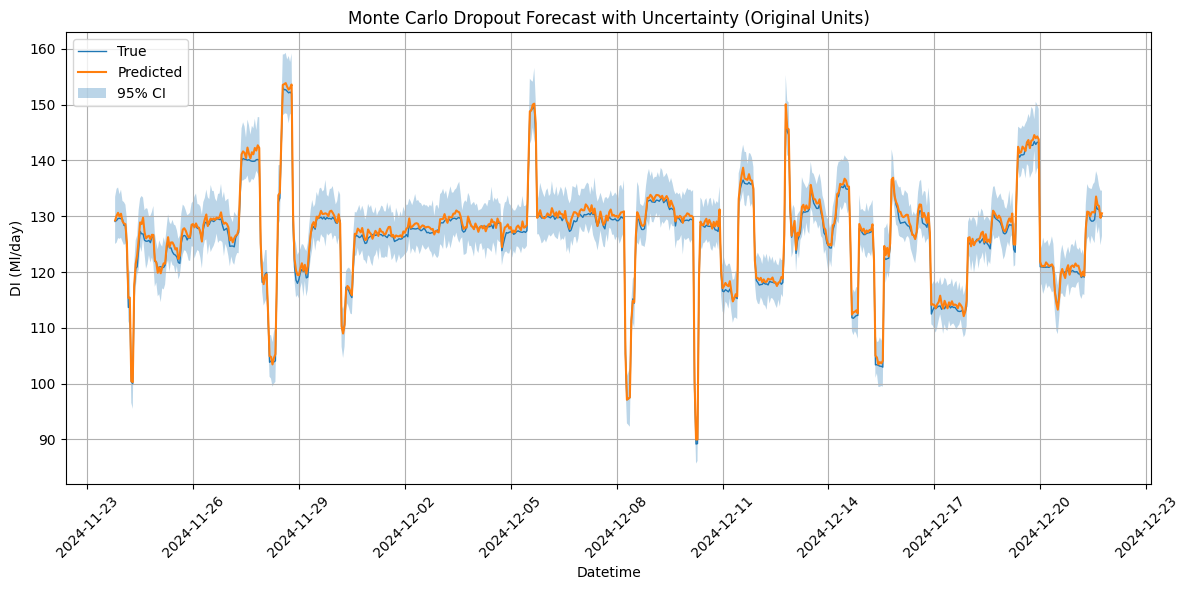

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pad predictions with zeros
X_dummy = np.zeros((mean_pred[0].shape[0], data.shape[1]))  # same feature count
X_dummy[:, data.columns.get_loc(target_col)] = mean_pred[0].flatten()
mean_inv = scaler.inverse_transform(X_dummy)[:, data.columns.get_loc(target_col)]

X_dummy[:, data.columns.get_loc(target_col)] = Y_test[0].flatten()
true_inv = scaler.inverse_transform(X_dummy)[:, data.columns.get_loc(target_col)]

# Convert std back to original units
std_inv = std_pred[0].flatten() * scaler.scale_[data.columns.get_loc(target_col)]

forecast_index = df.index[split_index + seq_len + label_len : split_index + seq_len + label_len + pred_len]


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(forecast_index, true_inv, label='True', linewidth=1)
ax.plot(forecast_index, mean_inv, label='Predicted', linewidth=1.5)
ax.fill_between(
    forecast_index,
    mean_inv - 1.96 * std_inv,
    mean_inv + 1.96 * std_inv,
    alpha=0.3,
    label='95% CI'
)

ax.set_xlabel("Datetime")
ax.set_ylabel("DI (Ml/day)")
ax.set_title("Monte Carlo Dropout Forecast with Uncertainty (Original Units)")
ax.legend()
ax.grid(True)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/tmp/ipython-input-26-340457153.py:24: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  forecast_index = pd.date_range(start=forecast_start, periods=672, freq='H')


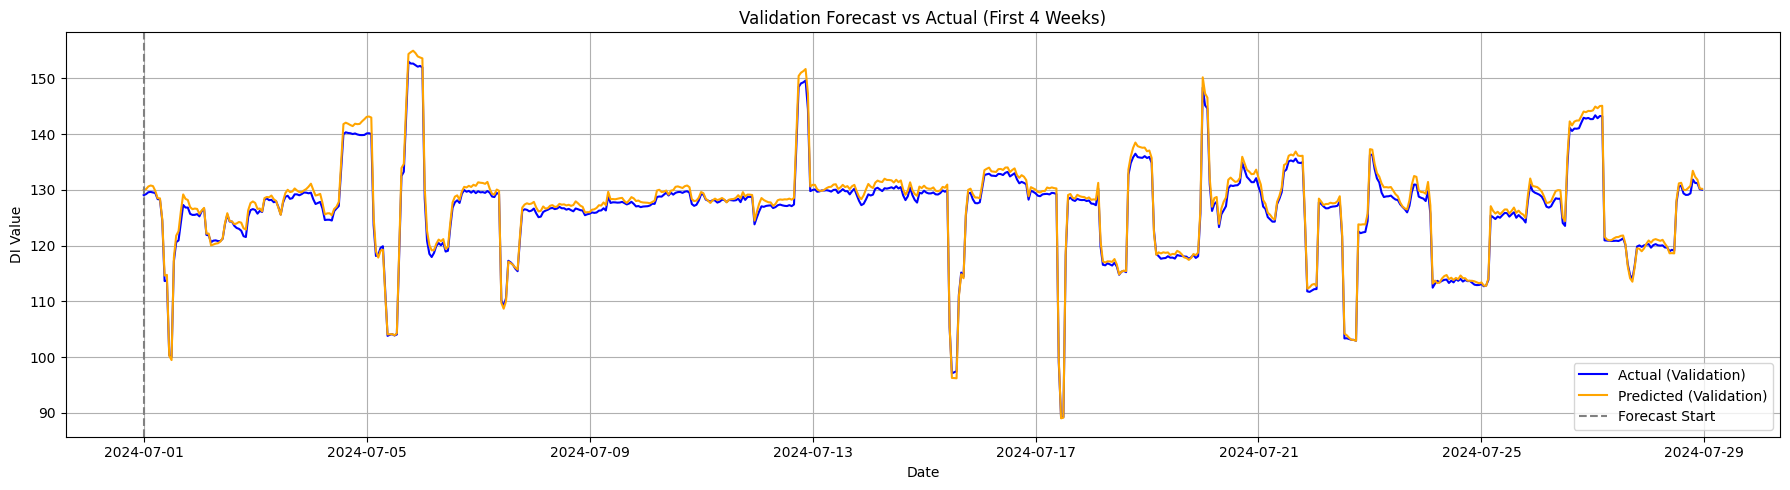

MAE: 0.86
RMSE: 1.00
MAPE: 0.67%
R² Score: 0.99


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score


# Predict 4 weeks from the first sample in validation set
Y_pred_scaled = model.predict([X_test_enc[:1], X_test_dec[:1]])  # shape: (1, 672, 1)

target_index = list(df.columns).index("Restormel 10SRE01")

# Reconstructing full feature shape for inverse_transform
pred_full = np.zeros((672, X_test_enc.shape[2]))
pred_full[:, target_index] = Y_pred_scaled[0, :, 0]
Y_pred = scaler.inverse_transform(pred_full)[:, target_index]

#actual values and inverse transformed predictions
true_full = np.zeros((672, X_test_enc.shape[2]))
true_full[:, target_index] = Y_test[0, :, 0]
Y_true = scaler.inverse_transform(true_full)[:, target_index]

forecast_start = pd.to_datetime("2024-07-01")
forecast_index = pd.date_range(start=forecast_start, periods=672, freq='H')

#plot actuals vs predicted
plt.figure(figsize=(18, 5))
plt.plot(forecast_index, Y_true, label="Actual (Validation)", color='blue')
plt.plot(forecast_index, Y_pred, label="Predicted (Validation)", color='orange')
plt.axvline(forecast_index[0], color='gray', linestyle='--', label="Forecast Start")
plt.title("Validation Forecast vs Actual (First 4 Weeks)")
plt.xlabel("Date")
plt.ylabel("DI Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#metrics
mae = mean_absolute_error(Y_true, Y_pred)
rmse = np.sqrt(mean_squared_error(Y_true, Y_pred))
mape = mean_absolute_percentage_error(Y_true, Y_pred)
r2 = r2_score(Y_true, Y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2%}")
print(f"R² Score: {r2:.2f}")


In [ ]:
# --- Inverse transform the prediction ---
# Create a full dummy array matching scaler's expected shape (n_samples, 6 features)
pred_scaled_full = np.zeros((pred_scaled.shape[0], scaler.mean_.shape[0]))  # shape: (672, 6)
pred_scaled_full[:, target_index] = pred_scaled  # insert predicted values at correct feature index

pred_actual = scaler.inverse_transform(pred_scaled_full)[:, target_index]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


/tmp/ipython-input-17-385757288.py:32: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  last_week_dates = pd.date_range(end=last_date, periods=168, freq='H')
/tmp/ipython-input-17-385757288.py:33: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  pred_dates = pd.date_range(start=last_date + timedelta(hours=1), periods=672, freq='H')


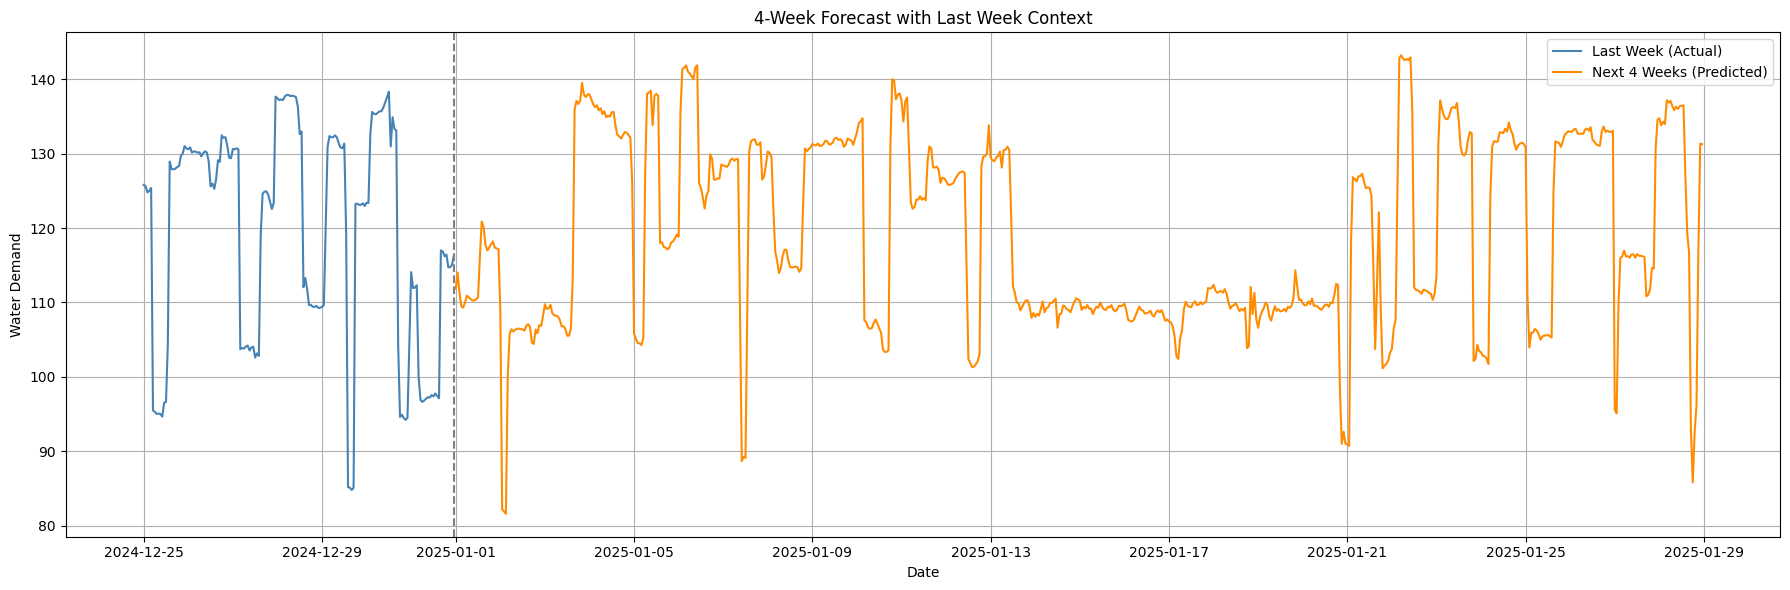

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

# Get model input
last_enc_input = X_test_enc[-1:]
last_dec_input = X_test_dec[-1:]

#predict
pred_scaled = model.predict((last_enc_input, last_dec_input))[0, :, 0]  # shape (672,)


num_features = scaler.mean_.shape[0]
pred_scaled_full = np.zeros((672, num_features))
pred_scaled_full[:, target_index] = pred_scaled
pred_actual = scaler.inverse_transform(pred_scaled_full)[:, target_index]


last_week_scaled = last_dec_input[0, :168, target_index]

last_week_full = np.zeros((168, num_features))
last_week_full[:, target_index] = last_week_scaled
last_week_actual = scaler.inverse_transform(last_week_full)[:, target_index]


last_date = df.index[-1]
last_week_dates = pd.date_range(end=last_date, periods=168, freq='H')
pred_dates = pd.date_range(start=last_date + timedelta(hours=1), periods=672, freq='H')

#plot 4 week future predictions
plt.figure(figsize=(18, 6))
plt.plot(last_week_dates, last_week_actual, label='Last Week (Actual)', color='steelblue')
plt.plot(pred_dates, pred_actual, label='Next 4 Weeks (Predicted)', color='darkorange')
plt.axvline(x=last_date, color='gray', linestyle='--')

plt.title('4-Week Forecast with Last Week Context')
plt.xlabel('Date')
plt.ylabel('Water Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
